In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import io

In [2]:
# fetch nifty 500 constitutents from wikipedia along with their sectors

url = 'https://en.wikipedia.org/wiki/NIFTY_500'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

nifty500_df = tables[4]

In [3]:
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)


In [4]:
display(nifty500_df['Industry'].value_counts())

,count
Industry,
Financial Services,92
Capital Goods,61
Healthcare,46
Chemicals,34
Automobile and Auto Components,33
Fast Moving Consumer Goods,31
Information Technology,25
Consumer Durables,25
Consumer Services,25


In [5]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
ticker_list = tickers.tolist()

In [6]:
# get raw OHLC data from yfinance

raw_data = yf.download(ticker_list, period='5y', interval='1d')

/tmp/ipykernel_47679/77886547.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_list, period='5y', interval='1d')
[***                    7%                       ]  34 of 500 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GMRINFRASTRUCT.NS"}}}
[***********           22%                       ]  109 of 500 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SWANENERGY.NS"}}}
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['GMRINFRASTRUCT.NS', 'SWANENERGY.NS', 'SUVENPHAR.NS', 'TATAMOTORS.NS', 'ISEC.NS', 'PEL.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [7]:
nifty500_index = yf.download('^CRSLDX', period='5y', interval='1d')

/tmp/ipykernel_47679/3257877420.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty500_index = yf.download('^CRSLDX', period='5y', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [17]:
closing_prices = raw_data['Close']
benchmark = nifty500_index['Close']

In [18]:
closing_prices = closing_prices.dropna(axis=1)

In [20]:
common_idx = closing_prices.index.intersection(benchmark.index).sort_values()
closing_prices = closing_prices.loc[common_idx]
benchmark = benchmark.loc[common_idx]

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(closing_prices, benchmark, test_size=0.2, shuffle=False)

In [22]:
log_returns = np.log(X_train/X_train.shift(1)).dropna()

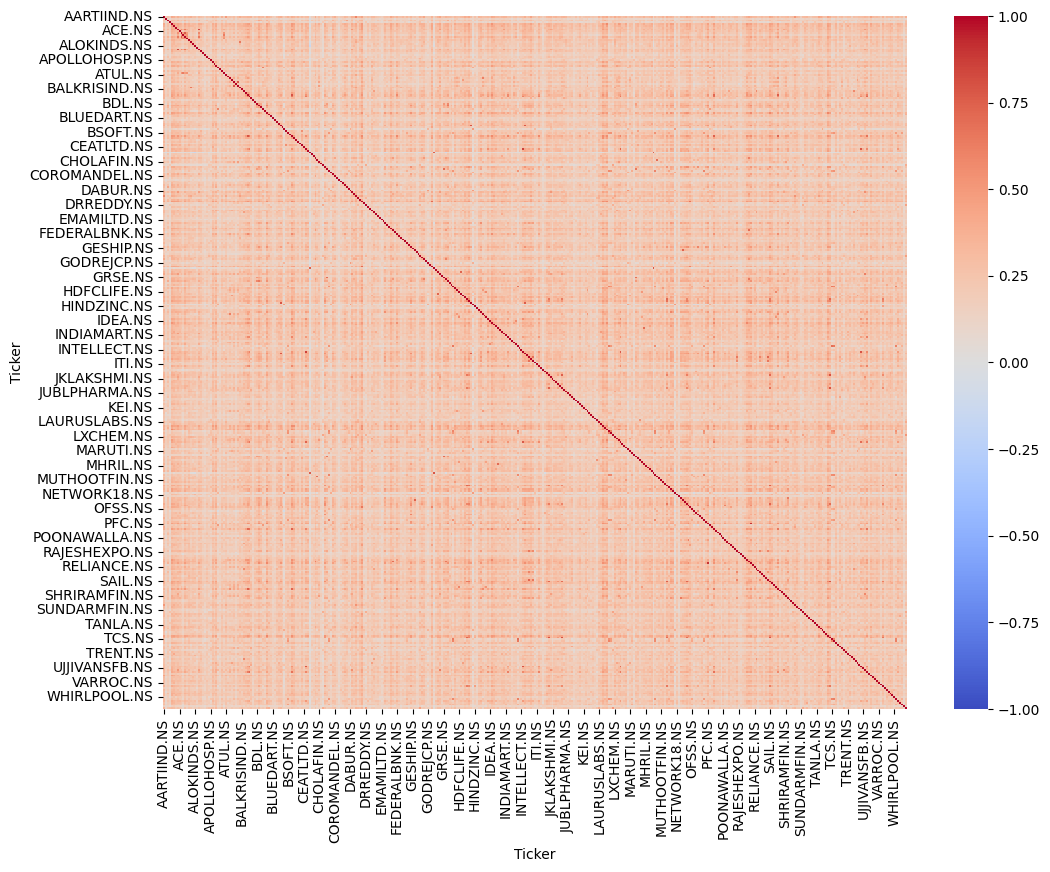

In [23]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [24]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [25]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([90.15617605, 10.53751069,  6.41590903,  5.42079942,  4.59603731,
        4.15899019,  3.53238799,  3.17069931,  3.0356569 ,  2.79501341])

array([0.23515501, 0.02748507, 0.01673466, 0.01413911, 0.01198788,
       0.01084792, 0.00921355, 0.00827016, 0.00791793, 0.00729025])

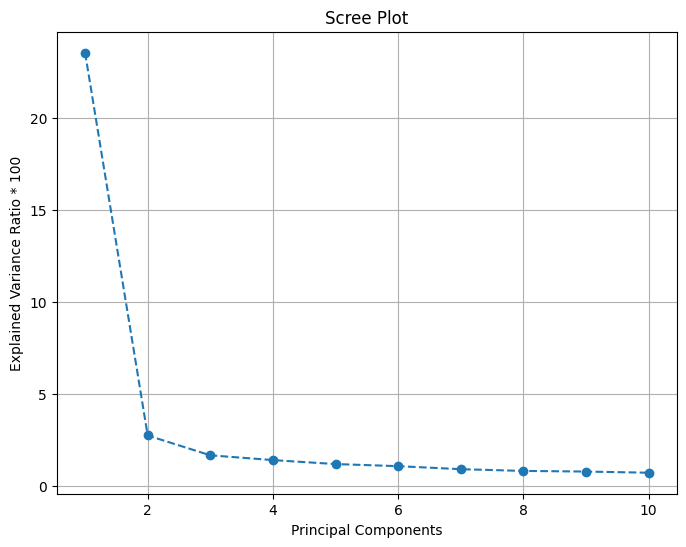

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [27]:
industry_map = (
    nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry']
)

In [28]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
102,DLF.NS,7.768344,Realty
342,TATAPOWER.NS,7.569784,Power
66,CANBK.NS,7.502714,Financial Services
226,LICHSGFIN.NS,7.450386,Financial Services
312,SAIL.NS,7.403018,Metals & Mining
157,HINDCOPPER.NS,7.311527,Metals & Mining
228,LTF.NS,7.308087,Financial Services
53,BHEL.NS,7.256449,Capital Goods
169,IDFCFIRSTB.NS,7.151483,Financial Services
4,ABCAPITAL.NS,7.118520,Financial Services


,Ticker,Weight,Industry
252,MOTILALOFS.NS,2.661622,Financial Services
242,MAXHEALTH.NS,2.634682,Healthcare
265,NH.NS,2.596759,Healthcare
139,GPIL.NS,2.522313,Capital Goods
90,CRISIL.NS,2.410548,Financial Services
263,NESTLEIND.NS,2.407165,Fast Moving Consumer Goods
62,BRITANNIA.NS,2.341508,Fast Moving Consumer Goods
159,HINDUNILVR.NS,2.242420,Fast Moving Consumer Goods
82,CIPLA.NS,2.128191,Healthcare
75,CGCL.NS,1.164600,Financial Services


In [29]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
182,INFY.NS,14.988008,Information Technology
344,TCS.NS,13.931734,Information Technology
159,HINDUNILVR.NS,13.816960,Fast Moving Consumer Goods
229,LTIM.NS,13.593769,Information Technology
149,HCLTECH.NS,13.494790,Information Technology
345,TECHM.NS,13.018234,Information Technology
263,NESTLEIND.NS,12.524212,Fast Moving Consumer Goods
377,WIPRO.NS,12.425358,Information Technology
96,DABUR.NS,12.246662,Fast Moving Consumer Goods
28,ASIANPAINT.NS,12.118588,Consumer Durables


,Ticker,Weight,Industry
188,IRCON.NS,-8.641576,Construction
311,RVNL.NS,-8.815637,Construction
163,HUDCO.NS,-8.881581,Financial Services
190,IRFC.NS,-8.906334,Financial Services
307,RITES.NS,-9.081186,Construction
321,SJVN.NS,-9.102677,Power
359,UCOBANK.NS,-9.360839,Financial Services
235,MAHABANK.NS,-9.716946,Financial Services
185,IOB.NS,-9.884377,Financial Services
73,CENTRALBK.NS,-11.252349,Financial Services


In [30]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
316,SBIN.NS,16.164931,Financial Services
34,AXISBANK.NS,15.280634,Financial Services
43,BANKBARODA.NS,14.699970,Financial Services
164,ICICIBANK.NS,14.549567,Financial Services
66,CANBK.NS,12.677701,Financial Services
218,KOTAKBANK.NS,11.956242,Financial Services
283,PNB.NS,11.841381,Financial Services
38,BAJFINANCE.NS,11.824371,Financial Services
36,BAJAJFINSV.NS,11.544216,Financial Services
120,FEDERALBNK.NS,10.847904,Financial Services


,Ticker,Weight,Industry
253,MPHASIS.NS,-10.035837,Information Technology
64,BSOFT.NS,-10.189780,Information Technology
241,MASTEK.NS,-10.280107,Information Technology
278,PERSISTENT.NS,-10.282334,Information Technology
323,SONATSOFTW.NS,-10.356655,Information Technology
380,ZENSARTECH.NS,-10.462910,Information Technology
106,ECLERX.NS,-10.493879,Services
230,LTTS.NS,-11.021856,Information Technology
229,LTIM.NS,-11.709834,Information Technology
85,COFORGE.NS,-13.537480,Information Technology


In [31]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
156,HINDALCO.NS,17.781925,Metals & Mining
343,TATASTEEL.NS,16.305111,Metals & Mining
275,ONGC.NS,16.155638,Oil Gas & Consumable Fuels
149,HCLTECH.NS,15.801861,Information Technology
345,TECHM.NS,15.624107,Information Technology
182,INFY.NS,15.594541,Information Technology
259,NATIONALUM.NS,15.515574,Metals & Mining
205,JSWSTEEL.NS,15.512705,Metals & Mining
312,SAIL.NS,14.527495,Metals & Mining
377,WIPRO.NS,14.034286,Information Technology


,Ticker,Weight,Industry
86,COLPAL.NS,-8.435252,Fast Moving Consumer Goods
62,BRITANNIA.NS,-8.590974,Fast Moving Consumer Goods
179,INDIGOPNTS.NS,-8.767731,Consumer Durables
239,MARICO.NS,-8.778381,Fast Moving Consumer Goods
26,ASAHIINDIA.NS,-8.876455,Automobile and Auto Components
96,DABUR.NS,-8.920111,Fast Moving Consumer Goods
113,ENDURANCE.NS,-8.948452,Automobile and Auto Components
281,PIDILITIND.NS,-9.308713,Chemicals
159,HINDUNILVR.NS,-10.077098,Fast Moving Consumer Goods
136,GODREJCP.NS,-10.271965,Fast Moving Consumer Goods


### Performance Measurement

In [32]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" 🎯 STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 🎯 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),14.50%,9.82%
Volatility,17.73%,14.31%
Sharpe Ratio,0.48,0.27
Sortino Ratio,0.69,0.39
Max Drawdown,-15.49%,-14.82%
Calmar Ratio,0.94,0.66
Beta,1.18,1.00
Jensen's Alpha,4.01%,0.00%


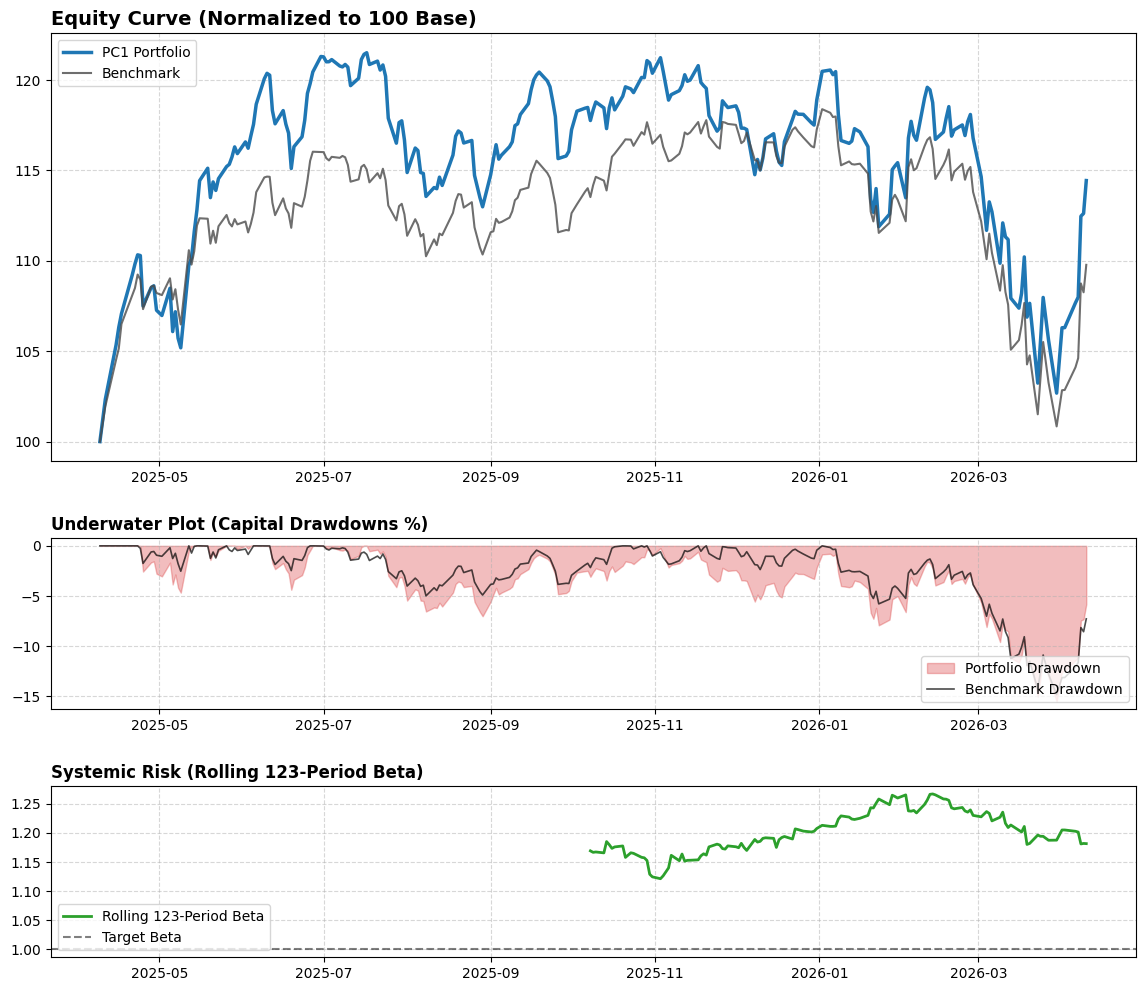

In [34]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=X_test, benchmark_data=Y_test, periods_per_yr=246)


 🎯 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-15.65%,9.82%
Volatility,15.94%,14.31%
Sharpe Ratio,-1.36,0.27
Sortino Ratio,-1.84,0.39
Max Drawdown,-17.86%,-14.82%
Calmar Ratio,-0.88,0.66
Beta,-0.56,1.00
Jensen's Alpha,-19.52%,0.00%


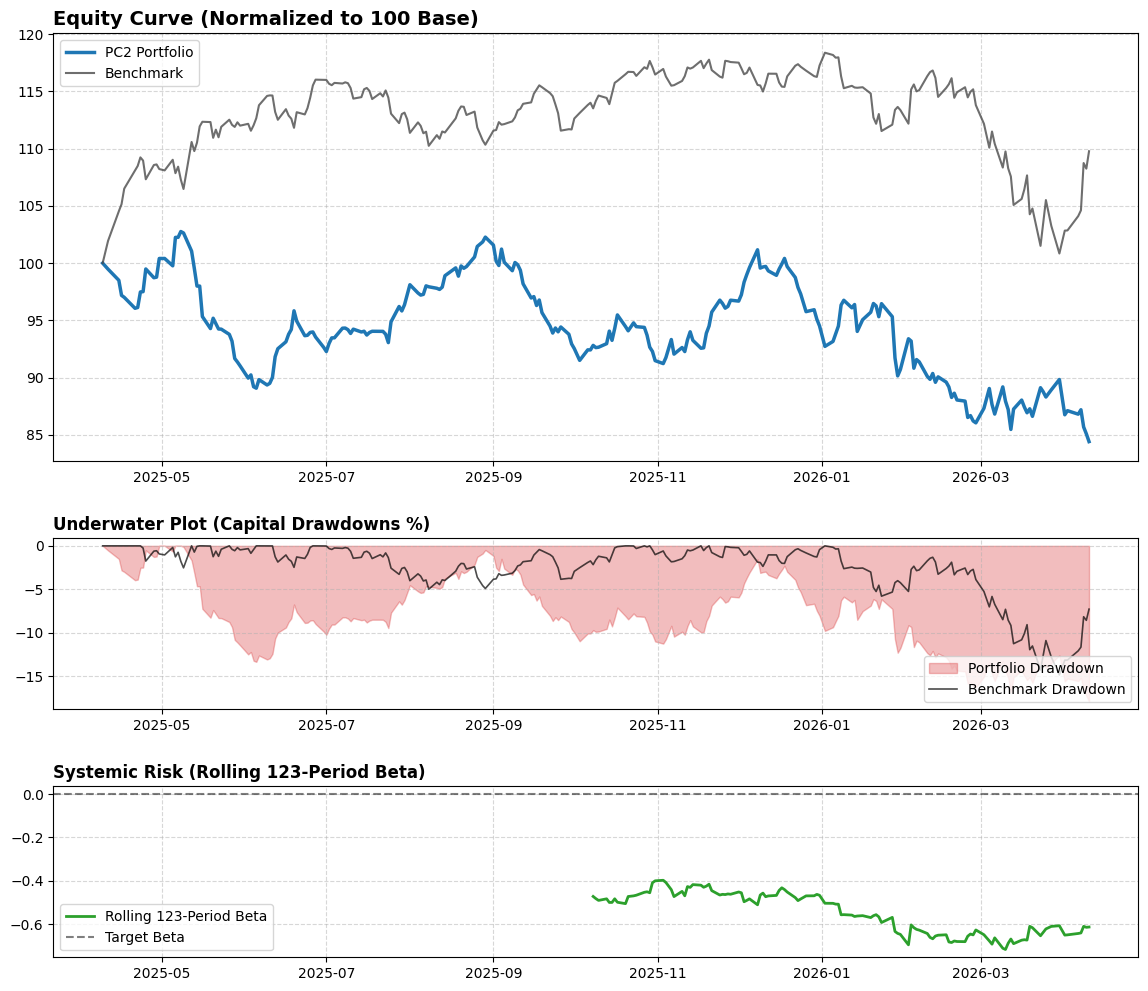

In [35]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=X_test, benchmark_data=Y_test, periods_per_yr=246)


 🎯 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),9.30%,9.82%
Volatility,11.44%,14.31%
Sharpe Ratio,0.29,0.27
Sortino Ratio,0.44,0.39
Max Drawdown,-11.72%,-14.82%
Calmar Ratio,0.79,0.66
Beta,0.08,1.00
Jensen's Alpha,3.01%,0.00%


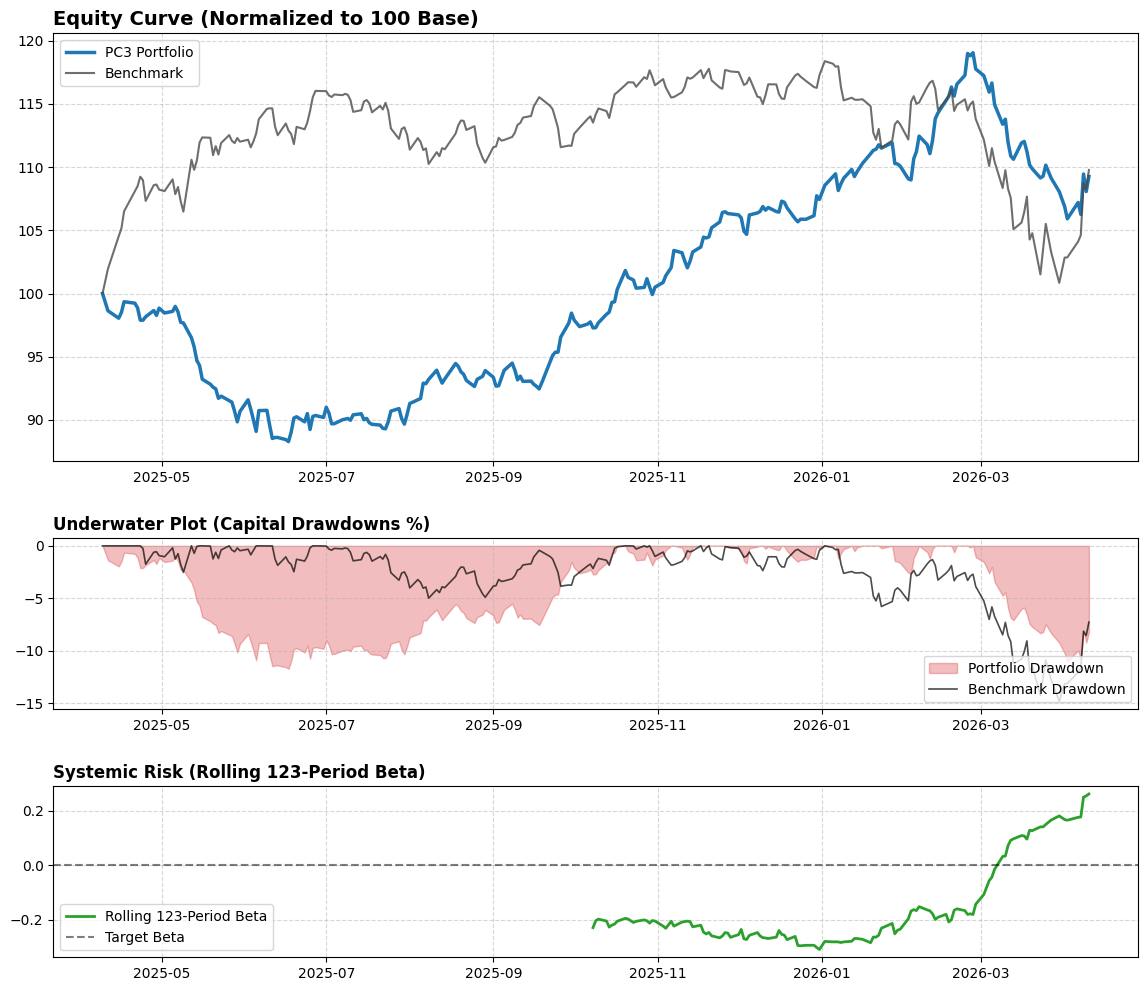

In [36]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=X_test, benchmark_data=Y_test, periods_per_yr=246)


 🎯 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),24.75%,9.82%
Volatility,11.00%,14.31%
Sharpe Ratio,1.70,0.27
Sortino Ratio,2.53,0.39
Max Drawdown,-8.70%,-14.82%
Calmar Ratio,2.84,0.66
Beta,0.09,1.00
Jensen's Alpha,18.39%,0.00%


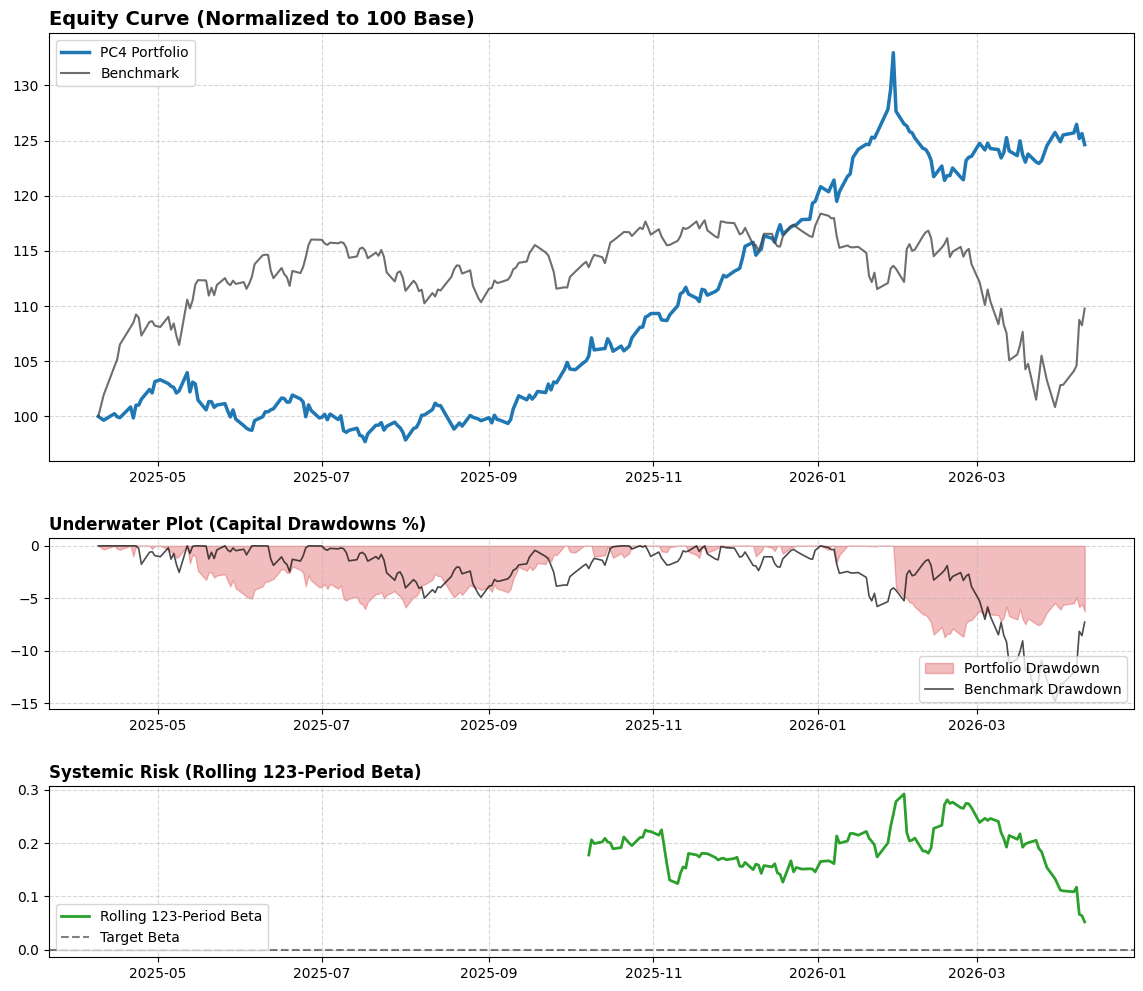

In [37]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=X_test, benchmark_data=Y_test, periods_per_yr=246)